## Implementing our NBC model in numpy

In [ ]:
import numpy as np

ALPHA = 1.0 # for additive smoothing
from scipy.stats import norm, bernoulli, multinomial

# Distribution for continuous features
class ContFeatureParam:

    def estimate(self, X):
        mu, std= norm.fit(X)
        if std == 0:
          std = 1e-6

        self.dist = norm(mu, std)

    def get_log_probability(self, X_new):
        return self.dist.logpdf(X_new)


class BinFeatureParam:

    def estimate(self, X):

        self.p = np.mean(X)

        n = len(X)
        n_1 = np.sum(X)

        self.p = (n_1 + ALPHA) / (n + 2 * ALPHA)

    def get_log_probability(self, X_new):

        log_prob = bernoulli.logpmf(X_new, self.p)
        return log_prob

class CatFeatureParam:

    def __init__(self, num_of_categories):
        self.num_of_categories = num_of_categories

    def estimate(self, X):
        # Number of occurrences
        counts = np.bincount(X, minlength= self.num_of_categories)

        # Here we apply Laplace
        self.theta = (counts + ALPHA) / (len(X) + ALPHA * self.num_of_categories)

    def get_log_probability(self, X_new):


        # We check if X_new has valid categories
        X_new = np.clip(X_new, 0, self.num_of_categories - 1)  # Ensure that the categories are in the range [0, num_of_categories-1]

        # We calculated the logarithmic probabilities for the categories
        log_probs = np.log(self.theta[X_new])

        return log_probs


class NBC:
    def __init__(self, feature_types=[]):
        self.feature_types = feature_types
        self.class_prior = None         # p(y)
        self.feature_parameters = {}    # p(x_j|y) for each feature j and class y
        self.classes = None

    def fit(self, X, y):


        self.classes, counts = np.unique(y, return_counts=True)
        num_classes = len(self.classes)
        num_features = X.shape[1]

        # We calculate the prior probabilities: p(y)
        self.class_prior = np.log(counts / len(y))

        # We estimate the parameters of the features by class and save them in self.feature_parameters --> (this is going to be our matrix with theta as in the slides)
        for i, c in enumerate(self.classes):
            self.feature_parameters[c] = []
            idx = np.where(y == c)[0]

            for j in range(num_features):
                feature_type = self.feature_types[j]
                X_j = X[idx, j]

                # check the type of feature:
                if feature_type == 'r':         # Continuous
                    param = ContFeatureParam()
                elif feature_type == 'b':       # Binary
                    param = BinFeatureParam()
                elif feature_type == 'c':       # Categorical
                    param = CatFeatureParam(num_of_categories=10)
                else:
                    raise ValueError(f"Unknown feature type: {feature_type}")

                param.estimate(X_j)
                self.feature_parameters[c].append(param)


    def predict(self, X):
        n_samples = X.shape[0]
        log_probs = np.zeros((n_samples, len(self.classes)))

        # p(y)
        for i, c in enumerate(self.classes):
            class_log_prob = self.class_prior[i]
        # We calculate the likelihood  p(x|y)
            for j, param in enumerate(self.feature_parameters[c]):
                feature_col = X[:, j]
                log_probs[:, i] += param.get_log_probability(feature_col)

            # We calculate the posterior probability for each class: p(y|x) = p(y) * p(x|y), but since it's logaritmic we sum the probabilities: log(p(y)) + log(p(x|y))
            log_probs[:, i] += class_log_prob


        return self.classes[np.argmax(log_probs, axis=1)]



## Trying out our NBC model on given datasets

In [ ]:
# the binary dataset

import pandas as pd
data = pd.read_csv('datasets/binary_test.csv', header=None)
data = data.to_numpy()

X = data[:,1:]
y = data[:,0]

N, D = X.shape
Ntrain = int(0.8 * N)
Xtrain = X[:Ntrain]
ytrain = y[:Ntrain]
Xtest = X[Ntrain:]
ytest = y[Ntrain:]


nbc = NBC(feature_types=['b'] * 16)
nbc.fit(Xtrain, ytrain)
yhat = nbc.predict(Xtest)
test_accuracy = np.mean(yhat == ytest)

print("Accuracy:", test_accuracy)
print(yhat)

Accuracy: 0.8723404255319149
[1 0 1 1 0 1 1 0 0 1 1 1 0 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 0 1 0
 0 0 1 0 0 0 0 1 1 0]


In [ ]:
# the categorical dataset

data = pd.read_csv('datasets/categorical_test.csv', header=None)
data = data.to_numpy()

X = data[:,:-1]
y = data[:,-1]

N, D = X.shape
Ntrain = int(0.8 * N)
Xtrain = X[:Ntrain]
ytrain = y[:Ntrain]
Xtest = X[Ntrain:]
ytest = y[Ntrain:]


nbc = NBC(feature_types=['c'] * 9)
nbc.fit(Xtrain, ytrain)
yhat = nbc.predict(Xtest)
test_accuracy = np.mean(yhat == ytest)

print("Accuracy:", test_accuracy)
print(yhat)

Accuracy: 0.7068965517241379
[0 1 0 1 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 1 0 1 0 0 0 0 1 0
 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0]


## Importing Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

## Code to comparing our NBC with the LR model

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

def compareNBCvsLR(nbc, lr, X, y, num_runs, num_splits):
    n = len(y)
    split_sizes = np.linspace(0.1, 0.9, num_splits)     # 10% to 90% of the data
    nbc_errors = np.zeros((num_runs, num_splits))
    lr_errors = np.zeros((num_runs, num_splits))


    for run in range(num_runs):
        # splitting into training and test set
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=run)
        for train_index, test_index in sss.split(X, y):
            X_shuffled_train, X_shuffled_test = X[train_index], X[test_index]
            y_shuffled_train, y_shuffled_test = y[train_index], y[test_index]


        for split_idx, split_size in enumerate(split_sizes):
            N_train = int(split_size * len(y_shuffled_train))

            X_train = X_shuffled_train[:N_train]
            y_train = y_shuffled_train[:N_train]
            X_test = X_shuffled_test
            y_test = y_shuffled_test

            # Naive Bayes Classifier
            nbc.fit(X_train, y_train)
            y_pred_nbc = nbc.predict(X_test)
            nbc_errors[run, split_idx] = np.mean(y_pred_nbc != y_test)

            # Logistic Regression Classifier
            # we also have to normalize the data for logistic regression and so we do
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            lr.fit(X_train, y_train)
            y_pred_lr = lr.predict(X_test)
            lr_errors[run, split_idx] = np.mean(y_pred_lr != y_test)


    avg_nbc_errors = np.mean(nbc_errors, axis=0)
    avg_lr_errors = np.mean(lr_errors, axis=0)

    return avg_nbc_errors, avg_lr_errors


In [ ]:
def makePlot(nbc_perf, lr_perf, title=None, num_splits=10):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    ax.tick_params(axis='both', labelsize=20)

    ax.set_xlabel('Percent of training data used', fontsize=20)
    ax.set_ylabel('Classification Error', fontsize=20)
    if title is not None: ax.set_title(title, fontsize=25)

    xaxis_scale = [(i + 1) * (100/num_splits) for i in range(num_splits)]
    plt.plot(xaxis_scale, nbc_perf, label='Naive Bayes')
    plt.plot(xaxis_scale, lr_perf, label='Logistic Regression', linestyle='dashed')

    ax.legend(loc='upper right', fontsize=20)

# DATASETS

## DATASET 1: VOTING DATASET

In [ ]:
voting = pd.read_csv('datasets/voting.csv')

print("Voting shape:", voting.shape)
voting.head()

Voting shape: (435, 17)


,label,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,republican,n,y,n,y,y,y,n,n,n,y,NaN,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,NaN
2,democrat,NaN,y,y,NaN,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,NaN,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,NaN,y,y,y,y


In [ ]:
print(" VOTING DATA INFO ")
voting.info()
print("\n VOTING DESCRIPTION ")
display(voting.describe(include='all'))

 VOTING DATA INFO 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   label                                   435 non-null    object
 1   handicapped-infants                     423 non-null    object
 2   water-project-cost-sharing              387 non-null    object
 3   adoption-of-the-budget-resolution       424 non-null    object
 4   physician-fee-freeze                    424 non-null    object
 5   el-salvador-aid                         420 non-null    object
 6   religious-groups-in-schools             424 non-null    object
 7   anti-satellite-test-ban                 421 non-null    object
 8   aid-to-nicaraguan-contras               420 non-null    object
 9   mx-missile                              413 non-null    object
 10  immigration                             428 non-null   

,label,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
count,435,423,387,424,424,420,424,421,420,413,428,414,404,410,418,407,331
unique,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,democrat,n,y,y,n,y,y,y,y,y,y,n,n,y,y,n,y
freq,267,236,195,253,247,212,272,239,242,207,216,264,233,209,248,233,269


### HANDLING THE MISSING VALUES

We replace all the missing values by the statistical mode value in that feature column.

In [ ]:
def fill_with_mode(df):
    df = df.copy()
    for col in df.columns:
        modes = df[col].mode(dropna=True)
        if not modes.empty:
            df[col].fillna(modes.iloc[0], inplace=True)
    return df

voting = fill_with_mode(voting)

voting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   label                                   435 non-null    object
 1   handicapped-infants                     435 non-null    object
 2   water-project-cost-sharing              435 non-null    object
 3   adoption-of-the-budget-resolution       435 non-null    object
 4   physician-fee-freeze                    435 non-null    object
 5   el-salvador-aid                         435 non-null    object
 6   religious-groups-in-schools             435 non-null    object
 7   anti-satellite-test-ban                 435 non-null    object
 8   aid-to-nicaraguan-contras               435 non-null    object
 9   mx-missile                              435 non-null    object
 10  immigration                             435 non-null    object
 11  synfue

### HANDLING FEATURE DATA TYPES

Since all the features are of object type, we convert them to integers for NBC and Logisitic regression models to work. Also, since they are just categorical in binary fashion without any order (all being 'y' or 'n'), so we use simple mapping of 'y' to 1 and 'n' to 0. Moreover, the label class can also be mapped into binary fashion.

In [ ]:
voting = voting.replace('y', 1)
voting = voting.replace('n', 0)
voting = voting.replace('republican', 1)
voting = voting.replace('democrat', 0)

C:\Users\nisha\AppData\Local\Temp\ipykernel_29384\1724267781.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  voting = voting.replace('n', 0)
C:\Users\nisha\AppData\Local\Temp\ipykernel_29384\1724267781.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  voting = voting.replace('democrat', 0)


### DATA VISUALIZATION

we explore:
- Class distribution
- Missing values pattern
- Feature correlations
- Feature vs. label relationships
- PCA-based 2D projection for visualizing feature separability

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

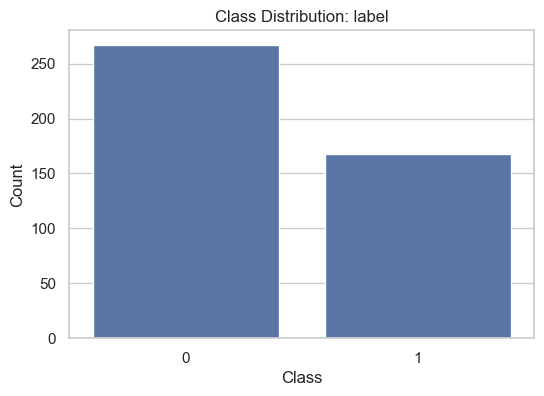

In [ ]:
## class distribution

plt.figure(figsize=(6,4))
sns.countplot(x=voting['label'])
plt.title("Class Distribution: label")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

As we can see above, the dataset is not balanced.

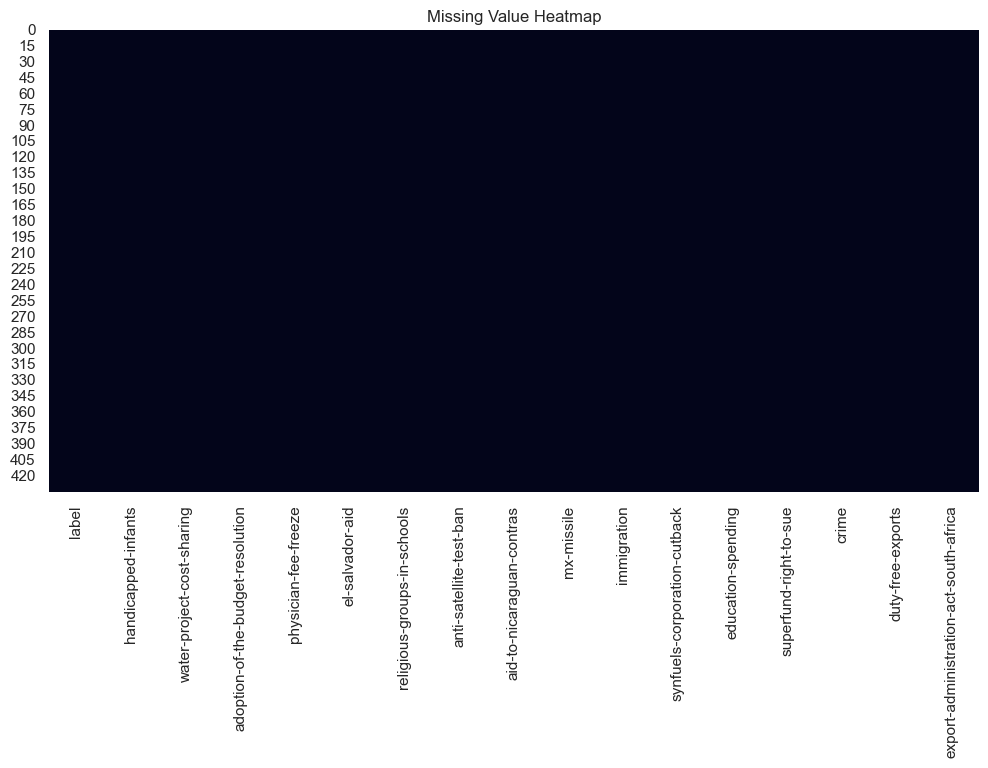

In [ ]:
## generating heatmaps for the missing values

plt.figure(figsize=(12,6))
sns.heatmap(voting.isna(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

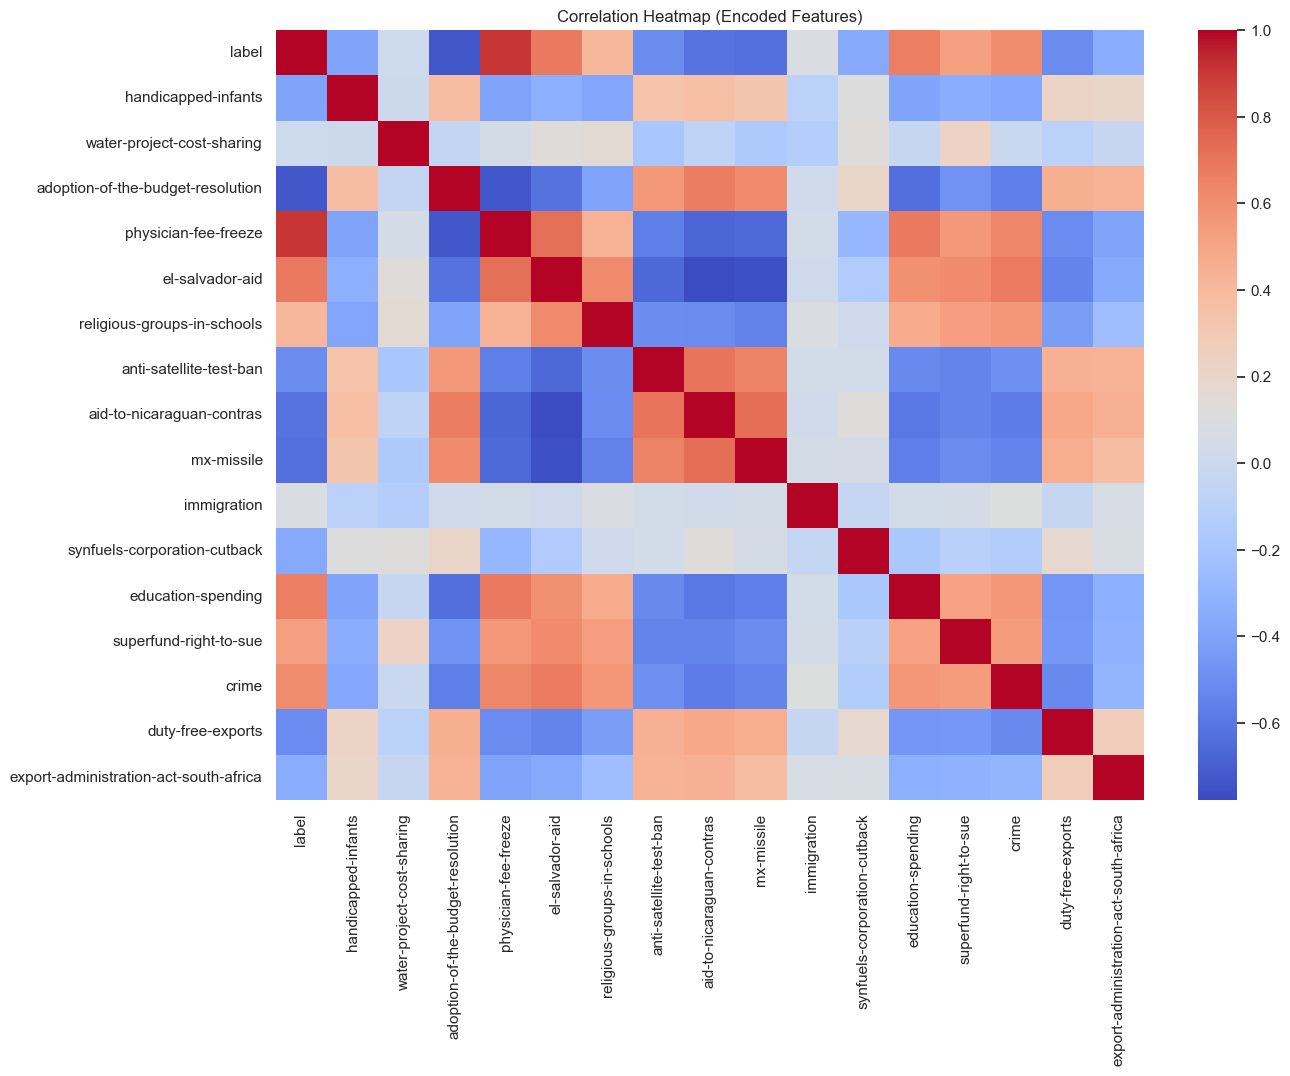

In [ ]:
## Correlation Heatmap (After One-Hot Encoding)

plt.figure(figsize=(14,10))
corr = voting.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Encoded Features)")
plt.show()

Above, we can identify groups of votes/features correlated with party label.

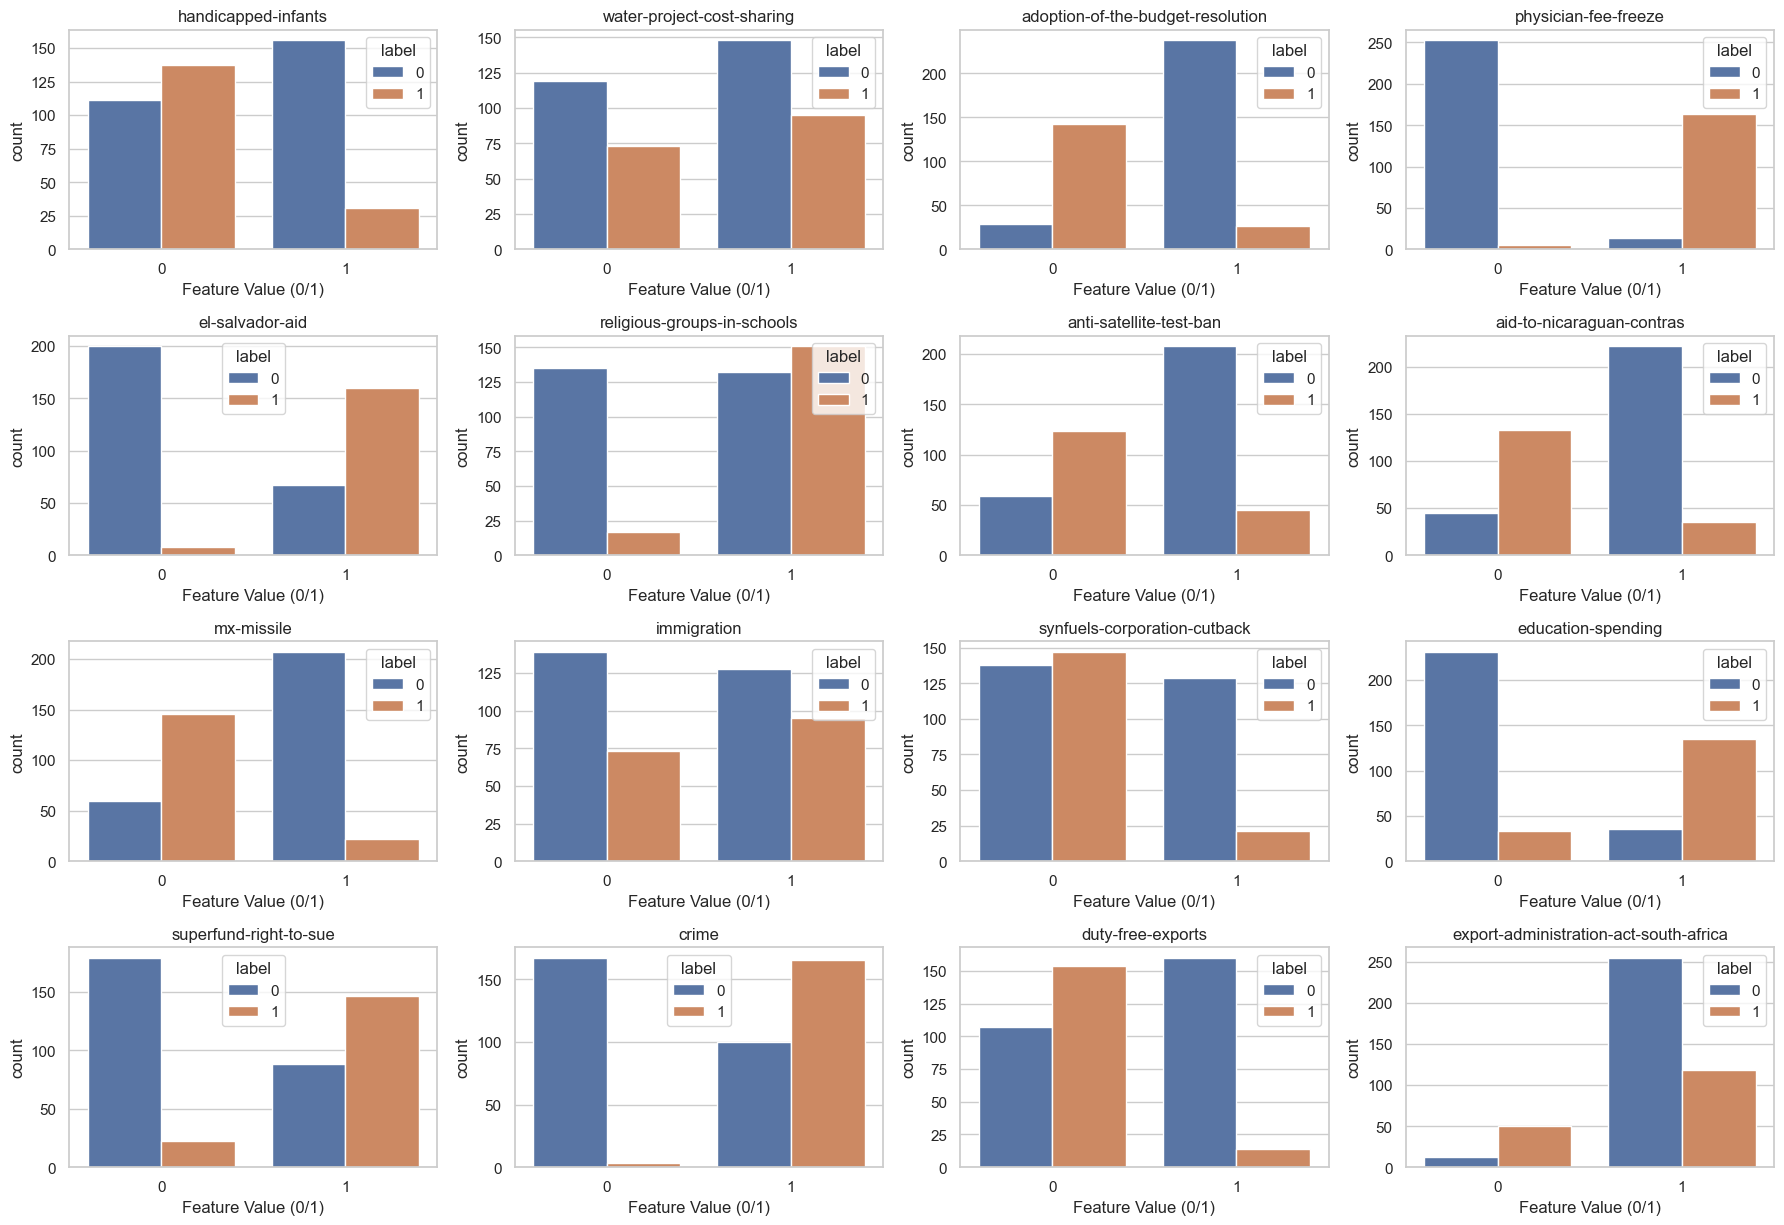

In [ ]:
## having feature vs. label countplots (All Features)

encoded = voting.copy()
feature_cols = [c for c in encoded.columns if c != "label"]

num_cols = len(feature_cols)
rows = (num_cols // 4) + 1

plt.figure(figsize=(18, rows * 3))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(rows, 4, i)
    sns.countplot(x=encoded[col], hue=encoded["label"])
    plt.title(col)
    plt.xlabel("Feature Value (0/1)")
    plt.tight_layout()

plt.show()

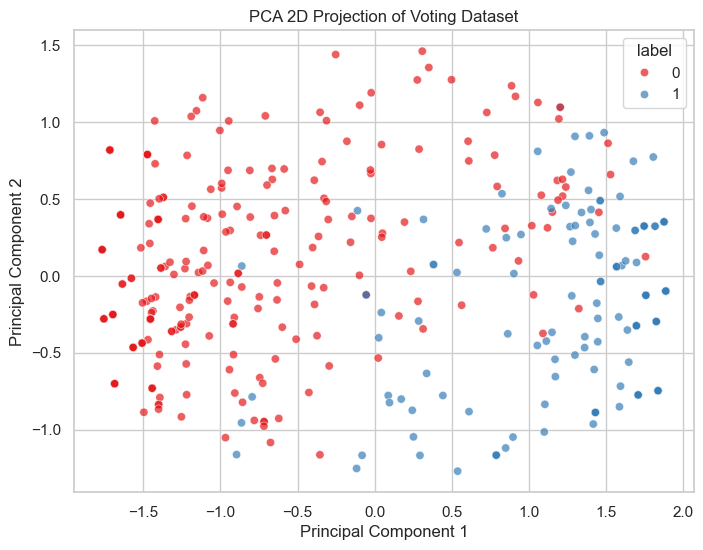

In [ ]:
## PCA 2D Visualization since it is a binary dataset

from sklearn.decomposition import PCA

X = voting.drop("label", axis=1)
y = voting["label"]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette="Set1",
    alpha=0.7
)
plt.title("PCA 2D Projection of Voting Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### SPLITTING TRAIN AND TEST SETS & EVALUATING

[[0 1 0 1 1 1 0 0 0 1 0 1 1 1 0 1]
 [0 1 0 1 1 1 0 0 0 0 0 1 1 1 0 1]
 [0 1 1 0 1 1 0 0 0 0 1 0 1 1 0 0]
 [0 1 1 0 1 1 0 0 0 0 1 0 1 0 0 1]
 [1 1 1 0 1 1 0 0 0 0 1 0 1 1 1 1]
 [0 1 1 0 1 1 0 0 0 0 0 0 1 1 1 1]
 [0 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1]
 [0 1 0 1 1 1 0 0 0 0 0 0 1 1 0 1]
 [0 1 0 1 1 1 0 0 0 0 0 1 1 1 0 1]
 [1 1 1 0 0 0 1 1 1 0 0 0 0 0 0 1]]
[1 1 0 0 0 0 0 1 1 0]
Avg NBC Error: [0.10097701 0.0995977  0.09931034 0.0983908  0.09724138 0.09752874
 0.09718391 0.09655172 0.09632184 0.09568966] & Avg LR Error: [0.06821839 0.05718391 0.05293103 0.05051724 0.0483908  0.04545977
 0.04425287 0.04367816 0.04235632 0.0416092 ]


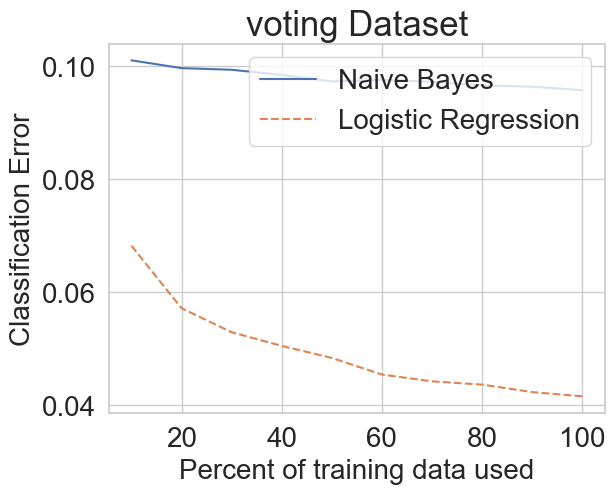

In [ ]:
X = voting.iloc[:, 1:]
y = voting.iloc[:, 0]

X = X.to_numpy()
y = y.to_numpy()

print(X[:10])   # looking at first 10 instance features
print(y[:10])   # looking at first 10 instance labels


nbc = NBC(feature_types=['b'] * 16)
lr = LogisticRegression()
nbc_perf, lr_perf = compareNBCvsLR(nbc, lr, X, y, num_runs=200, num_splits=10)

print(f"Avg NBC Error: {nbc_perf} & Avg LR Error: {lr_perf}")
makePlot(nbc_perf, lr_perf, title='voting Dataset')

CONCLUSION:

- Across te complete training-set sizes (10% → 100%), Logistic Regression achieves lower classification error than Naïve Bayes. This shows that the discriminative model is better suited to this binary dataset.
- The Naïve Bayes error curve is almost flat, barely improving as more data is added. If we refer the paper, this aligns witht the fact that the Generative models such as NBC reach their asymptotic errors very quickly. But their error is higher than discriminative models. So NBC saturates early and can't benefit much from more data.

## DATASET 2: BREAST CANCER DATASET

In [ ]:
cancer = pd.read_csv('datasets/breast-cancer.csv')

print("Cancer shape:", cancer.shape)
cancer.head()

Cancer shape: (286, 10)


,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [ ]:
print(" CANCER DATA INFO ")
cancer.info()
print("\n CANCER DESCRIPTION ")
display(cancer.describe(include='all'))

 CANCER DATA INFO 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class        286 non-null    object
 1   age          286 non-null    object
 2   menopause    286 non-null    object
 3   tumor-size   286 non-null    object
 4   inv-nodes    286 non-null    object
 5   node-caps    286 non-null    object
 6   deg-malig    286 non-null    int64 
 7   breast       286 non-null    object
 8   breast-quad  286 non-null    object
 9   irradiat     286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB

 CANCER DESCRIPTION 


,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
count,286,286,286,286,286,286,286.000000,286,286,286
unique,2,6,3,11,7,3,NaN,2,6,2
top,no-recurrence-events,50-59,premeno,30-34,0-2,no,NaN,left,left_low,no
freq,201,96,150,60,213,222,NaN,152,110,218
mean,NaN,NaN,NaN,NaN,NaN,NaN,2.048951,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.738217,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN


## DATA PREPROCESSING

As we observe different features have different data types - some are ordinal (ordered) and categorical. So we handle them accordingly.

In [ ]:
cancer = cancer.dropna()

# Ordinal features
ordinal_columns = ['age', 'tumor-size', 'inv-nodes', 'deg-malig']

# Categorical features:
non_ordinal_columns = ['node-caps', 'breast', 'breast-quad', 'irradiat', 'menopause', 'Class']

# Encoding ordinal features
for column in ordinal_columns:
    cancer[column] = cancer[column].astype('category').cat.codes

# One-hot encode non-ordinal columns
cancer = pd.get_dummies(cancer, columns=non_ordinal_columns)

cancer = cancer.replace({False: 0, True: 1})

C:\Users\nisha\AppData\Local\Temp\ipykernel_29384\1950114202.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cancer = cancer.replace({False: 0, True: 1})


In [ ]:
cancer.head()

,age,tumor-size,inv-nodes,deg-malig,node-caps_?,node-caps_no,node-caps_yes,breast_left,breast_right,breast-quad_?,...,breast-quad_left_up,breast-quad_right_low,breast-quad_right_up,irradiat_no,irradiat_yes,menopause_ge40,menopause_lt40,menopause_premeno,Class_no-recurrence-events,Class_recurrence-events
0,1,5,0,2,0,1,0,1,0,0,...,0,0,0,1,0,0,0,1,1,0
1,2,3,0,1,0,1,0,0,1,0,...,0,0,1,1,0,0,0,1,1,0
2,2,3,0,1,0,1,0,1,0,0,...,0,0,0,1,0,0,0,1,1,0
3,4,2,0,1,0,1,0,0,1,0,...,1,0,0,1,0,1,0,0,1,0
4,2,0,0,1,0,1,0,0,1,0,...,0,1,0,1,0,0,0,1,1,0


### DATA VISUALIZATIOM

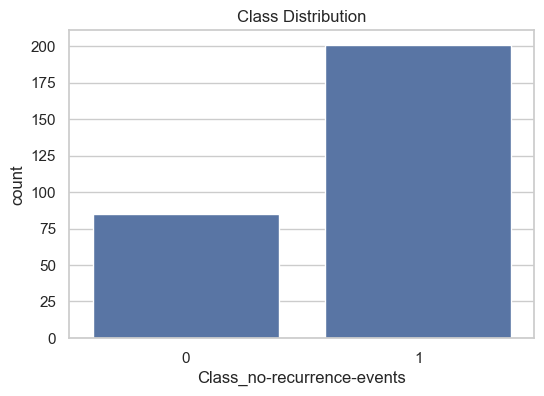

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# One class of the the target variable
plt.figure(figsize=(6,4))
sns.countplot(data=cancer, x='Class_no-recurrence-events')
plt.title("Class Distribution")
plt.show()

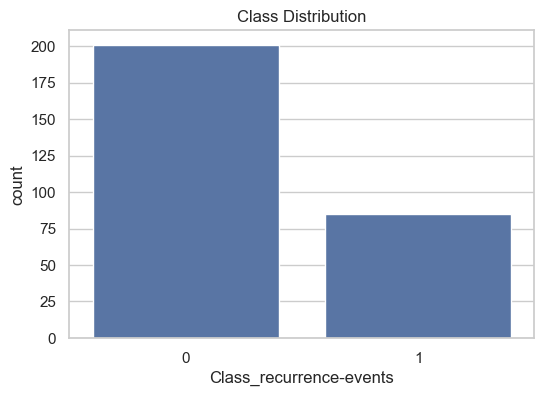

In [ ]:
# Other class of the the target variable
plt.figure(figsize=(6,4))
sns.countplot(data=cancer, x='Class_recurrence-events')
plt.title("Class Distribution")
plt.show()

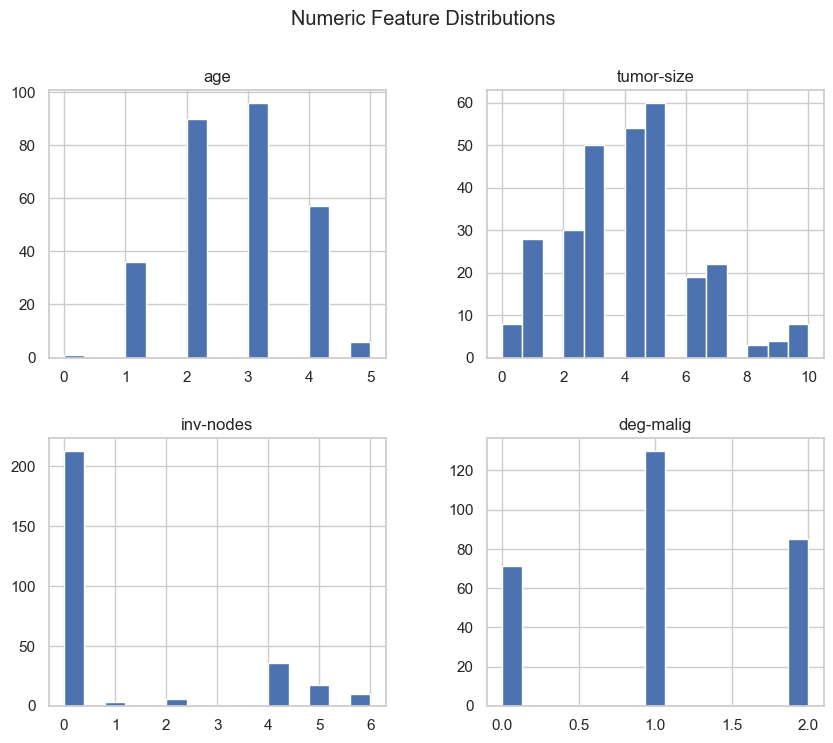

In [ ]:
# Distribution of the numeric features
num_cols = ['age', 'tumor-size', 'inv-nodes', 'deg-malig']

cancer[num_cols].hist(figsize=(10,8), bins=15)
plt.suptitle("Numeric Feature Distributions")
plt.show()

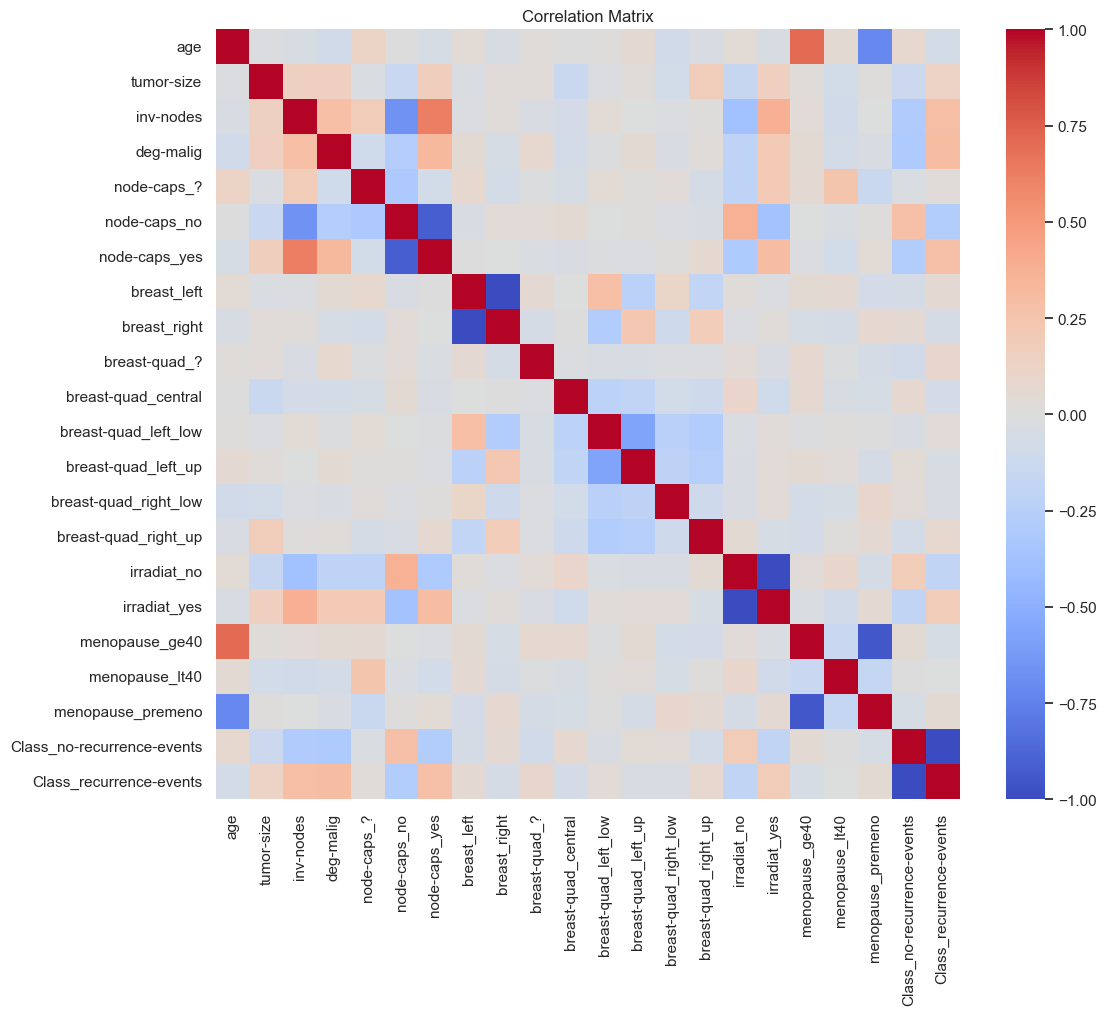

In [ ]:
# The correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(cancer.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

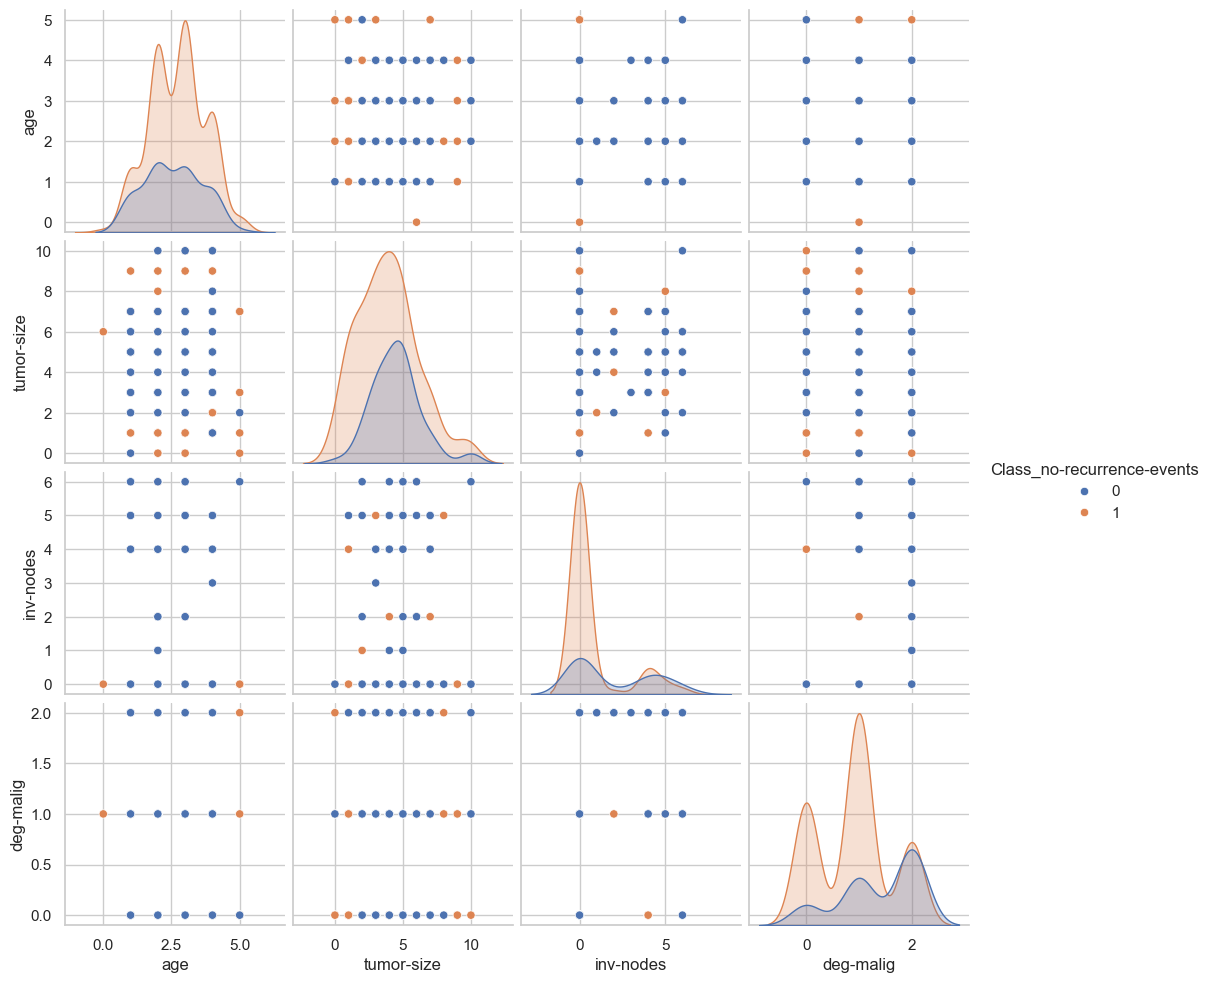

In [ ]:
# The pairplot for the numeric features
sns.pairplot(cancer, vars=num_cols, hue="Class_no-recurrence-events")
plt.show()

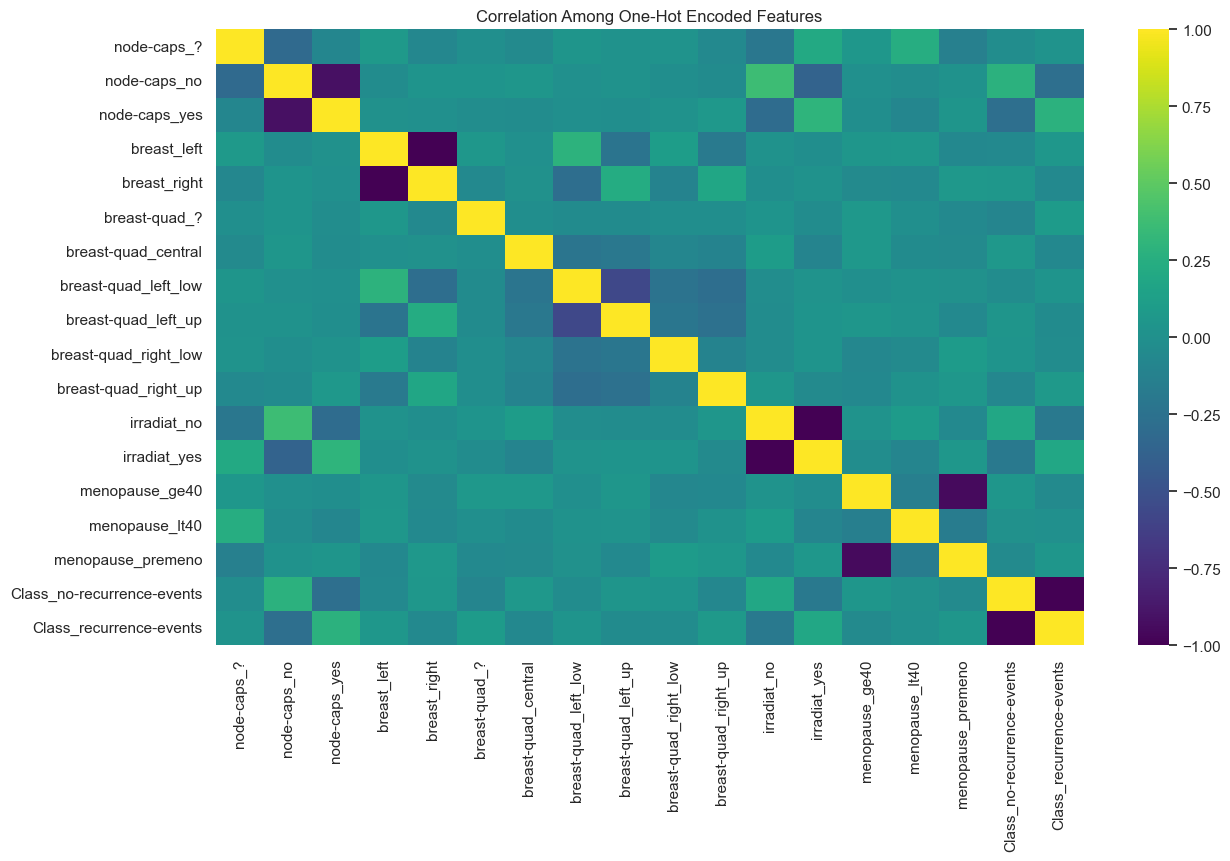

In [ ]:
# Heatmap of category counts
cat_cols = [col for col in cancer.columns if col not in num_cols + ['Class']]
plt.figure(figsize=(14,8))
sns.heatmap(cancer[cat_cols].corr(), annot=False, cmap="viridis")
plt.title("Correlation Among One-Hot Encoded Features")
plt.show()

### SPLITTING THE TRAIN AND TEST SETS & EVALUATING

[[ 1  5  0  2  0  1  0  1  0  0  0  1  0  0  0  1  0  0  0  1]
 [ 2  3  0  1  0  1  0  0  1  0  0  0  0  0  1  1  0  0  0  1]
 [ 2  3  0  1  0  1  0  1  0  0  0  1  0  0  0  1  0  0  0  1]
 [ 4  2  0  1  0  1  0  0  1  0  0  0  1  0  0  1  0  1  0  0]
 [ 2  0  0  1  0  1  0  0  1  0  0  0  0  1  0  1  0  0  0  1]
 [ 4  2  0  1  0  1  0  1  0  0  0  1  0  0  0  1  0  1  0  0]
 [ 3  4  0  1  0  1  0  1  0  0  0  1  0  0  0  1  0  0  0  1]
 [ 4  3  0  0  0  1  0  1  0  0  0  1  0  0  0  1  0  1  0  0]
 [ 2 10  0  1  0  1  0  1  0  0  0  1  0  0  0  1  0  0  0  1]
 [ 2  3  0  1  0  1  0  0  1  0  0  0  1  0  0  1  0  0  0  1]]
['Class_no-recurrence-events' 'Class_no-recurrence-events'
 'Class_no-recurrence-events' 'Class_no-recurrence-events'
 'Class_no-recurrence-events' 'Class_no-recurrence-events'
 'Class_no-recurrence-events' 'Class_no-recurrence-events'
 'Class_no-recurrence-events' 'Class_no-recurrence-events']
Avg NBC Error: [0.31612069 0.28982759 0.28775862 0.28508621 0.28103448 0.

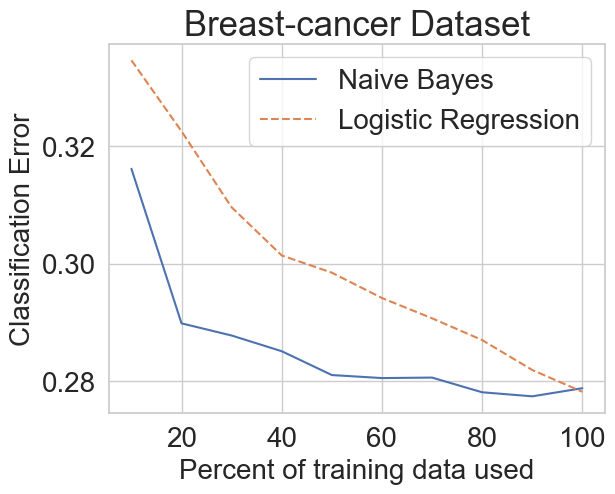

In [ ]:
X = cancer.iloc[:, :-2]  # All columns except the last two, which are our Y labels
y = cancer.iloc[:, -2:]  # The last two columns, are 'Class_no-recurrence-events' and 'Class_recurrence-events'

# Binary label where 0 = 'Class_no-recurrence-events' and 1 = 'Class_recurrence-events':
y = y.idxmax(axis=1)


X = X.to_numpy()
y = y.to_numpy()


print(X[:10])       # looking at first 10 instance features
print(y[:10])       # looking at first 10 instance labels

num_features = X.shape[1]


feature_types = ['r'] * len(ordinal_columns) + ['b'] * (num_features - len(ordinal_columns))
nbc = NBC(feature_types=feature_types)
lr = LogisticRegression(max_iter=10000)
nbc_perf, lr_perf = compareNBCvsLR(nbc, lr, X, y, num_runs=200, num_splits=10)

print(f"Avg NBC Error: {nbc_perf} & Avg LR Error: {lr_perf}")
makePlot(nbc_perf, lr_perf, title='Breast-cancer Dataset')

CONCLUSION:

- Across all the training dataset sizes, the Naïve Bayes performs better than the Logistic Regression. The NBC curve is consistently below the LR curve.
This denotes that the Generative Model (NBC) achieves lower classification error whereas the discriminative model (LR) struggles more on this categorical dataset.
- NBC converges quickly and reaches its asymptotic error early. It drops sharply at small sample sizes, flattens out by 40–60% of training data and stabilizes around 0.28 error. On the other hand, the Logistic Regression improves slowly and never catches NBC. This tells us that the discriminative models (LR) have lower asymptotic error only if the linear model is well-specified. In categorical datasets with many correlated features, LR can underperform NB. Here, LR struggles, maybe because the categorical features are binary but not linearly separable.